# 04 — Default Model: Cox Proportional Hazards

Spec §5.3. Data source: `panel_cph_2018_2025.parquet` (2018–2025 originations).

**Why CPH instead of logistic regression here:**  
Loans still performing at the observation end are right-censored — not confirmed
non-defaults. Logistic regression treats them as true zeros, biasing coefficients
downward. Cox PH conditions on the risk set at each event time, using censored
loans correctly up to their last observed month.

Pipeline:
1. Load 2018-2025 panel (never load the logistic panel here)
2. Aggregate to survival tuples with ELTV LOCF imputation
3. Random stratified train/test split
4. Fit CoxPHFitter(penalizer=0.1)
5. Print summary and check proportional hazards assumption
6. Compute C-index on test set
7. Plot baseline survival curve and partial hazard effects
8. Serialize model

In [19]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

# NOTE: select the pyenv "Python 3 (ipykernel)" kernel, not the anaconda one —
# the anaconda env has a broken cv2/NumPy combination that crashes the kernel.
load_dotenv()
sys.path.insert(0, str(Path('..') / 'src'))
import feature_engineering as fe
import survival_model as sm

PROCESSED = Path('..') / 'data' / 'processed'
FIGURES   = Path('..') / 'artifacts' / 'figures'
MODELS    = Path('..') / 'artifacts' / 'models'
FIGURES.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

## 1. Load precomputed loan-level survival table

The full `panel_cph_2018_2025.parquet` (6.7 GB / 592M rows) does **not** fit in a
16 GB kernel. We load the one-row-per-loan survival table built out-of-core with
DuckDB via `python src/build_model_aggregates.py`, which already encodes the
delinquency ordinal, ELTV LOCF imputation, and per-loan duration/event tuples.

We also load `eda_vintage.parquet` (default rate by origination quarter, computed
from the CPH panel) to confirm the resolved 2018–2020 terminal events are present
(spec §10 Phase 2 check) without rescanning the panel.

In [20]:
# One row per loan, built out-of-core with DuckDB (see build_model_aggregates.py).
survival_path = PROCESSED / 'loan_level_survival.parquet'
if not survival_path.exists():
    raise FileNotFoundError(
        f'{survival_path} not found. First run:\n'
        '    python src/build_model_aggregates.py'
    )
survival_loan = pd.read_parquet(survival_path)
print(f'Survival loan-level table: {survival_loan.shape[0]:,} loans × {survival_loan.shape[1]} cols')

# Confirm 2018-2020 cohorts (with resolved terminal events) are present.
vintage = pd.read_parquet(PROCESSED / 'eda_vintage.parquet')
early = vintage[vintage['orig_quarter'].str[:4].isin(['2018', '2019', '2020'])]
print('\nLoan-level default rate by 2018-2020 origination quarter:')
print(early.to_string(index=False))
assert (early['default_rate'] > 0).all(), 'Missing resolved defaults in 2018-2020 cohorts!'
print('\n2018-2020 terminal events present (spec §10 Phase 2 check) ✓')

Survival loan-level table: 15,280,573 loans × 14 cols

Loan-level default rate by 2018-2020 origination quarter:
orig_quarter  default_rate
      2018Q1      5.872489
      2018Q2      5.339466
      2018Q3      5.300018
      2018Q4      5.384894
      2019Q1      5.319978
      2019Q2      5.325171
      2019Q3      5.342057
      2019Q4      5.151273
      2020Q1      5.240962
      2020Q2      3.107469
      2020Q3      1.525281
      2020Q4      1.284699

2018-2020 terminal events present (spec §10 Phase 2 check) ✓


## 2. Finalize survival features + stratified subsample

`build_survival_features_from_loan_level` applies median imputation, z-score
standardization, and log transforms. The full population is ~15.3M loans —
fitting lifelines on that many rows is intractable on 16 GB, so we draw an
event-stratified subsample (preserves the rare event rate) for the Cox fit.

In [21]:
survival_full = fe.build_survival_features_from_loan_level(survival_loan)
print(f'Full survival dataset: {survival_full.shape[0]:,} loans')

# Event-stratified subsample for a tractable Cox fit on 16 GB (preserves event rate).
COX_SAMPLE_SIZE = 2_000_000
survival_df = sm.stratified_subsample(survival_full, n_target=COX_SAMPLE_SIZE, seed=42)

print(f'Subsampled to: {survival_df.shape[0]:,} loans')
print(f'Event rate (ever 90+DPD): {survival_df.event.mean():.4%} '
      f'(full population: {survival_full.event.mean():.4%})')
print(f'Max duration: {survival_df.duration.max()} months')
print(f'Censoring rate: {(1-survival_df.event).mean():.1%}')
survival_df[['duration', 'event', 'fico_z', 'orig_cltv_z', 'delinq_last']].describe().round(3)

Full survival dataset: 15,280,573 loans
Subsampled to: 2,000,000 loans
Event rate (ever 90+DPD): 2.4784% (full population: 2.4784%)
Max duration: 92 months
Censoring rate: 97.5%


,duration,event,fico_z,orig_cltv_z,delinq_last
count,2000000.000,2000000.000,2000000.000,2000000.000,2000000.000
mean,37.727,0.025,-0.000,0.001,0.029
std,21.018,0.155,1.000,0.978,0.270
min,0.000,0.000,-10.169,-3.754,0.000
25%,18.000,0.000,-0.677,-0.618,0.000
50%,41.000,0.000,0.201,0.139,0.000
75%,55.000,0.000,0.808,0.680,0.000
max,92.000,1.000,1.978,50.101,3.000


## 3. Random stratified train / test split

In [22]:
train_df, valid_df, test_df = sm.temporal_split_survival(survival_df, train_frac=0.70, valid_frac=0.15)
for name, split in [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]:
    print(f'{name:5s}: {len(split):>8,} loans | event rate {split.event.mean():.4%}')

Train: 1,400,000 loans | event rate 2.4726%
Valid:  300,000 loans | event rate 2.5177%
Test :  300,000 loans | event rate 2.4663%


## 4. Fit CoxPHFitter

In [23]:
train_valid = pd.concat([train_df, valid_df])  # fit on combined train+valid
cph = sm.train_cox(train_valid, penalizer=0.1)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1.7e+06 total observations, 1.65783e+06 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1.7e+06
number of events observed = 42169
   partial log-likelihood = -514579.94
         time fit was run = 2026-06-22 20:08:36 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
fico_z          -0.12      0.89      0.00           -0.12           -0.11                0.89                0.89
orig_cltv_z      0.05      1.05      0.00            0.05            0.06                1.05                1.06
orig_dti_z       0.07      1.07      0.00            0.06            0.07                1.07                1.08
current_rate_z   0.07      1.07      0.00            0.06            0.07                1.06                1.07
eltv_last_z      0.09      1.09      0.00            0.08            0.09                1.09                1.10
log_orig_upb     0.06      1.06      0.00            0.05            0.07                1.05                1.07
log_current_upb -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
occ_investment  -0.03      0.97      0.01           -0.04           -0.01                0.96                0.99
occ_second      -0.08      0.93      0.01           -0.10           -0.05                0.90                0.95
delinq_last      1.10      3.01      0.00            1.09            1.11                2.99                3.03

                 cmp to      z      p  -log2(p)
covariate                                      
fico_z             0.00 -53.97 <0.005       inf
orig_cltv_z        0.00  24.17 <0.005    426.48
orig_dti_z         0.00  31.50 <0.005    721.00
current_rate_z     0.00  28.39 <0.005    586.44
eltv_last_z        0.00  38.69 <0.005       inf
log_orig_upb       0.00  15.09 <0.005    168.52
log_current_upb    0.00 -43.81 <0.005       inf
occ_investment     0.00  -2.82 <0.005      7.72
occ_second         0.00  -6.34 <0.005     31.99
delinq_last        0.00 283.29 <0.005       inf
---
Concordance = 0.91
Partial AIC = 1029179.88
log-likelihood ratio test = 62670.06 on 10 df
-log2(p) of ll-ratio test = inf

## 5. Proportional hazards assumption check (Schoenfeld residuals)

Covariates with p < 0.05 violate the PH assumption — their effect is not constant
over loan age. Typical violations: FICO (strong early, weakens over time), ELTV
(strengthens as loan ages into negative equity).

In [24]:
# The PH test (scaled Schoenfeld residuals) is O(n_events × n) in lifelines — it
# loops over every event time in Python, so on the full 1.7M-row train_valid it runs
# for hours. We diagnose on a 100k subsample instead.
#
# NOTE: check_assumptions reuses the FITTED model's stored _n_examples to build its
# internal weight vector, so the dataframe passed in must have the same row count as
# the data the model was fit on — you can't feed a subsample to the full-data `cph`
# (it raises a length-mismatch ValueError). So we fit a lightweight diagnostic model
# on the subsample and test PH on that same data. PH violations are about functional
# form and hold regardless of sample size, so the conclusions carry over to `cph`.
ph_sample = train_valid.sample(n=100_000, random_state=42).reset_index(drop=True)
cph_diag = sm.train_cox(ph_sample, penalizer=0.1)
ph_results = sm.check_proportional_hazards(cph_diag, ph_sample, p_value_threshold=0.05)
print('\n(PH test run on a 100k-row diagnostic model — production model is the full-data `cph`.)')
print('Note: Covariates with p<0.05 violate PH assumption.')
print('Fix options: (1) include time-interaction term, (2) stratify baseline hazard')

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'current_rate_z' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'current_rate_z' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'current_rate_z' using pd.cut, and then specify it in
`strata=['current_rate_z', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'eltv_last_z' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'eltv_last_z' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below 

## 6. C-index on test set

In [25]:
c_idx = sm.cox_c_index(cph, test_df)
print(f'C-index (test set): {c_idx:.4f}')
print('Interpretation: fraction of admissible pairs correctly ranked by risk')
print('Expect > 0.70 for a well-specified mortgage default model')

C-index (test set): 0.9068
Interpretation: fraction of admissible pairs correctly ranked by risk
Expect > 0.70 for a well-specified mortgage default model


## 7. Baseline survival curve and covariate effects

/var/folders/fv/pf_pqm6s2ds43tstk6b5q3wm0000gn/T/ipykernel_74079/1844339357.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  partial_hazards.append(float(cph.predict_partial_hazard(pd.DataFrame([row]))))
/var/folders/fv/pf_pqm6s2ds43tstk6b5q3wm0000gn/T/ipykernel_74079/1844339357.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  partial_hazards.append(float(cph.predict_partial_hazard(pd.DataFrame([row]))))
/var/folders/fv/pf_pqm6s2ds43tstk6b5q3wm0000gn/T/ipykernel_74079/1844339357.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  partial_hazards.append(float(cph.predict_partial_hazard(pd.DataFrame([row]))))
/var/folders/fv/pf_pqm6s2ds43tstk6b5q3wm0000gn/T/ipykernel_74079/1844339357.py:

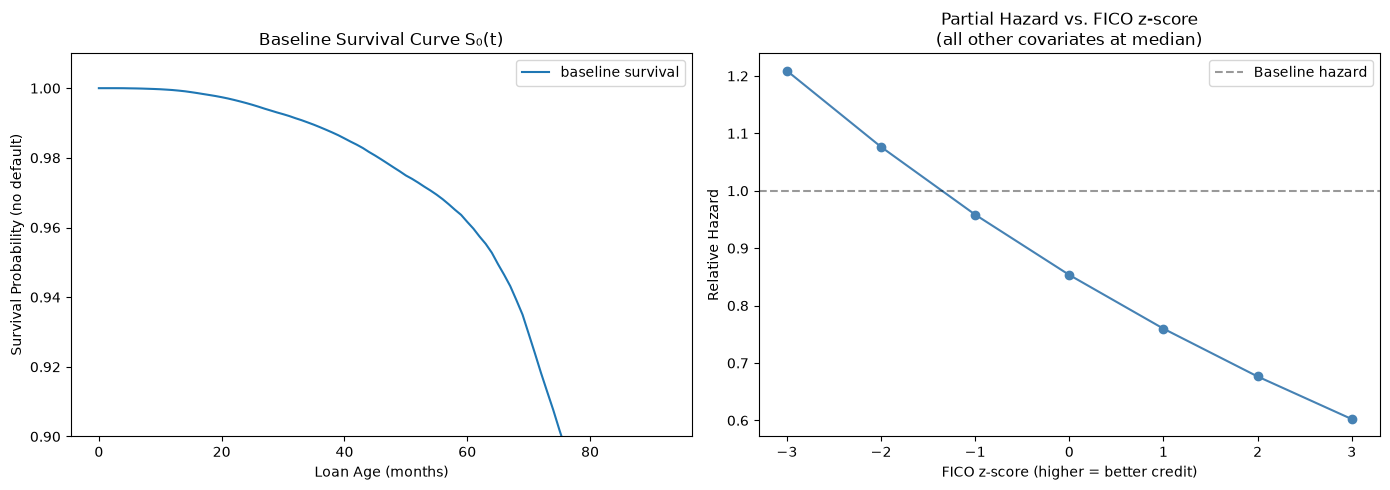

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline survival curve (median covariate values)
cph.baseline_survival_.plot(ax=axes[0])
axes[0].set_title('Baseline Survival Curve S₀(t)')
axes[0].set_xlabel('Loan Age (months)')
axes[0].set_ylabel('Survival Probability (no default)')
axes[0].set_ylim(0.9, 1.01)

# Partial hazard plot: vary FICO z-score, fix everything else at median
median_row = survival_df[sm.CPH_FEATURE_COLS].median()
fico_range = np.linspace(-3, 3, 7)
partial_hazards = []
for fico_z in fico_range:
    row = median_row.copy()
    row['fico_z'] = fico_z
    partial_hazards.append(float(cph.predict_partial_hazard(pd.DataFrame([row]))))

axes[1].plot(fico_range, partial_hazards, 'o-', color='steelblue')
axes[1].axhline(1.0, color='k', linestyle='--', alpha=0.4, label='Baseline hazard')
axes[1].set_title('Partial Hazard vs. FICO z-score\n(all other covariates at median)')
axes[1].set_xlabel('FICO z-score (higher = better credit)')
axes[1].set_ylabel('Relative Hazard')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'cox_survival_and_hazard.png', bbox_inches='tight')
plt.show()

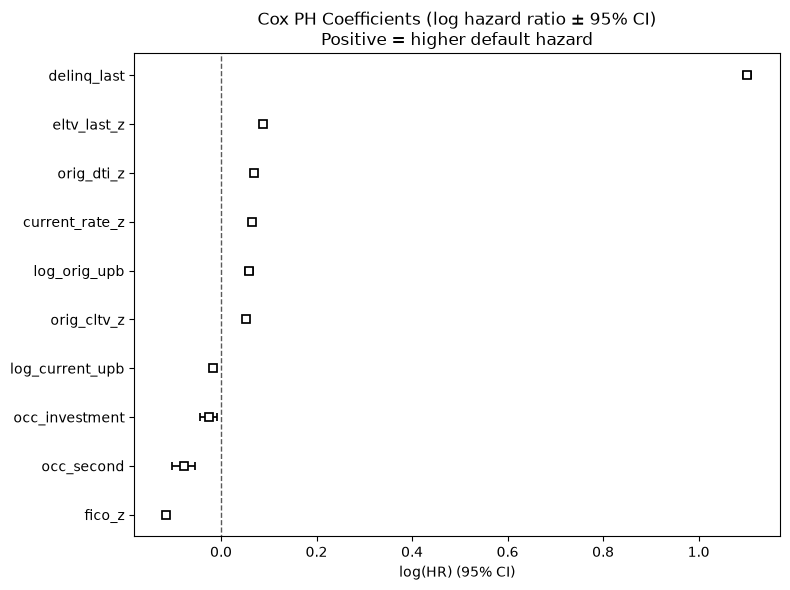

In [27]:
# Coefficient forest plot
fig, ax = plt.subplots(figsize=(8, 6))
cph.plot(ax=ax)
ax.set_title('Cox PH Coefficients (log hazard ratio ± 95% CI)\nPositive = higher default hazard')
plt.tight_layout()
plt.savefig(FIGURES / 'cox_coefficients.png', bbox_inches='tight')
plt.show()

## 8. Serialize model

In [28]:
model_path = sm.save_cox_model(cph, out_dir=MODELS)
print(f'Cox model saved to: {model_path}')

# Verify round-trip
cph_loaded = sm.load_cox_model(model_path)
c_idx_reload = sm.cox_c_index(cph_loaded, test_df)
assert abs(c_idx - c_idx_reload) < 1e-6, 'C-index differs after reload!'
print(f'Round-trip load: C-index matches ({c_idx_reload:.4f}) ✓')

Cox model saved to: ../artifacts/models/cox_ph_model.pkl
Round-trip load: C-index matches (0.9068) ✓
